1. Business Objective

To examine the forecast whether a customer will default on a loan credit history using historical credit and customer data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Loan Data set _19.2.26.csv")
print(df.head())
print(df.info())

  Gender Married Dependents     Education Self_Employed  Applicant_Income  \
0   Male     Yes          0      Graduate            No            572000   
1   Male     Yes          1      Graduate            No            307600   
2   Male     Yes          2      Graduate            No            500000   
3   Male     Yes          2      Graduate            No            234000   
4   Male      No          0  Not Graduate            No            327600   

   Coapplicant_Income  Loan_Amount   Term  Credit_History   Area  
0                   0     11000000  360.0             1.0  Urban  
1              150000     12600000  360.0             1.0  Urban  
2              180000     20800000  360.0             1.0  Urban  
3              254600     10000000  360.0             NaN  Urban  
4                   0      7800000  360.0             1.0  Urban  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column              Non-N

2. Data Understanding

In [ ]:
print(df.describe())
# Missing values
print(df.isnull().sum())

       Applicant_Income  Coapplicant_Income   Loan_Amount        Term  \
count      3.670000e+02        3.670000e+02  3.670000e+02  361.000000   
mean       4.805599e+05        1.569578e+05  1.342779e+07  342.537396   
std        4.910685e+05        2.334232e+05  6.296143e+06   65.156643   
min        0.000000e+00        0.000000e+00  0.000000e+00    6.000000   
25%        2.864000e+05        0.000000e+00  1.000000e+07  360.000000   
50%        3.786000e+05        1.025000e+05  1.250000e+07  360.000000   
75%        5.060000e+05        2.430500e+05  1.575000e+07  360.000000   
max        7.252900e+06        2.400000e+06  5.500000e+07  480.000000   

       Credit_History  
count      338.000000  
mean         0.825444  
std          0.380150  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  
Gender                11
Married                0
Dependents            10
Education              0
Self_Employed         23
A

3. Data Preparation

In [ ]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# Encode categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

4. Target (DV) and Feature (IV) Variable

In [ ]:
X = df.drop('Credit_History', axis=1)
y = df['Credit_History']

Develop Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

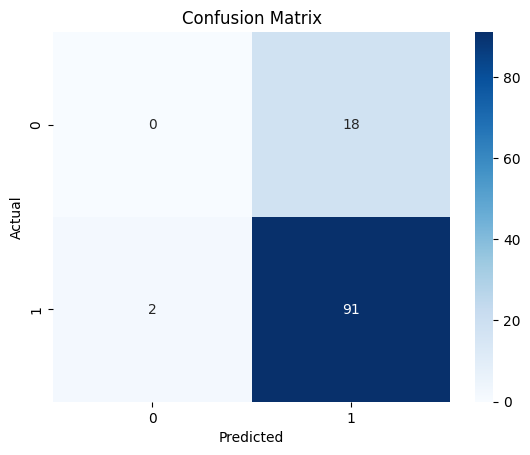

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score: 0.43369175627240153


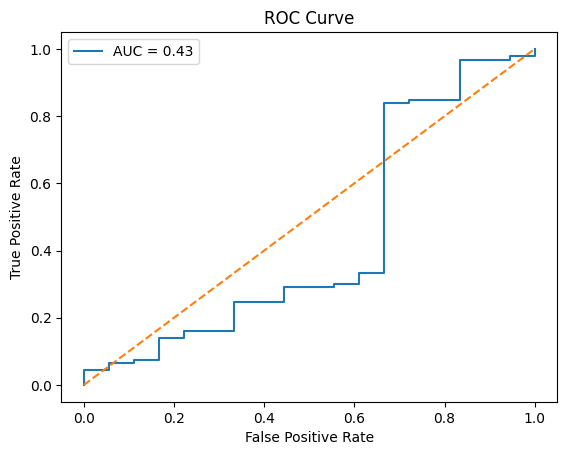

In [ ]:
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

              Feature  Coefficient
5    Applicant_Income     1.045823
9                Area     0.314683
1             Married     0.223030
6  Coapplicant_Income     0.063003
2          Dependents     0.023508
3           Education     0.017901
0              Gender    -0.010101
8                Term    -0.048082
4       Self_Employed    -0.282372
7         Loan_Amount    -0.327171


In [ ]:
#Forecasting New  credit Loan Default
new_customer = X_test.iloc[[0]]
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
probability = model.predict_proba(new_customer_scaled)
print("Default Prediction:", prediction[0])
print("Probability of Default:", probability[0][1])

Default Prediction: 1.0
Probability of Default: 0.7864596298359664
